# DDM Classification Results
Structured comparison across:
- **Curve type**: Ori Curve | Ori Curve Aligned | Ori Curve Aligned Normalised
- **Method**: Full 5-plex | One-to-One
- **Strategy**: Range (1_area / Z_area) | Area (3_range_filtered / Z_range_filtered)

> **Note**: folder names are swapped vs. biological meaning.
> `1_area / Z_area*` = **Range Strategy** | `3_range_filtered / Z_range_filtered*` = **Area Strategy**


## 0. Setup

In [1]:
import os, re, math
from itertools import combinations
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects
from sklearn.metrics import confusion_matrix
import importlib.util
%matplotlib inline

import os
try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(notebook_path))
except Exception:
    pass

import config

def _load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

prep01b = _load_module("prep01b", "01b_lab_curve_preprocessing.py")
stat08  = _load_module("stat08",  "08_statistical_comparison.py")



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



In [2]:
# ── Curve type ─────────────────────────────────────────────────────────────────
# Change CURVE_TYPE to switch which trained variant is shown everywhere.
# Options: "ori_curve" | "ori_curve_norm"
CURVE_TYPE = "ori_curve_norm"

RESULT_CURVE_KEY_MAP = {
    "ori_curve":              "Ori Curves",
    "ori_curve_norm":         "Ori Curves Norm",
    "ori_curve_avg":          "Ori Curves Avg",
    "ori_curve_wavelet_sym8": "Ori Curves Wavelet Sym8",
}

# ── Aligned flag ───────────────────────────────────────────────────────────────
# True  → load from *_aligned folders (recommended: includes TTP-filtered curves)
# False → load from original (non-aligned) folders
ALIGNED = True

# ── Training mode ──────────────────────────────────────────────────────────────
# "full" → LAB_DDM_paper Z_* folders (5-class, fold-to-fold std)
# "1to1" → LAB_OneToOne combos (binary pairs, combo-to-combo std)
TRAINING_MODE = "full"

# ── Strategy display names (folder names are biologically swapped) ──────────────
STRATEGY_DISPLAY_MAP = {
    "1_area":                       "Range Strategy",
    "3_range_filtered":             "Area Strategy",
    "Z_area":                       "Range Strategy",
    "Z_range_filtered":             "Area Strategy",
    "Z_area_aligned":               "Range Strategy (Aligned)",
    "Z_range_filtered_aligned":     "Area Strategy (Aligned)",
    "1_area_aligned":               "Range Strategy (Aligned)",
    "3_range_filtered_aligned":     "Area Strategy (Aligned)",
}

def display_name(key):
    """Correct display name for a folder/strategy key."""
    return STRATEGY_DISPLAY_MAP.get(key, key)

# ── Models ─────────────────────────────────────────────────────────────────────
MODELS       = ["knn", "cnn", "gru", "transformer",
                 "cnn_lf", "gru_lf", "trans_lf",
                 "cnn_gru_dual", "cnn_trans_dual"]
MODEL_LABEL_MAP = config.MODEL_PRINT_MAP
MODEL_FIXED_COLORS = {
    "cnn":         config.MODEL_COLORS["CNN"],
    "gru":         config.MODEL_COLORS["GRU"],
    "transformer": config.MODEL_COLORS["Transformer"],
}
MODEL_COLOR_MAP = config.get_palette(MODELS, MODEL_FIXED_COLORS)

# ── One-to-one combos ──────────────────────────────────────────────────────────
LAB_1TO1_FOLDER = Path(config.LAB_1TO1_EXP_FOLDER)
STRATEGIES  = sorted(prep01b.FILE_MAPPING_ONE_TO_ONE.keys())[::2]   # 1_area, 3_range_filtered
COMBOS      = prep01b.discover_one_to_one_combos(str(LAB_1TO1_FOLDER))
COMBOS      = COMBOS[:10] + COMBOS[-10:]
PAIRS       = sorted({f"{l1}_vs_{l2}" for _, l1, l2, _ in COMBOS})

# ── LAB_DDM_paper ↔ 1to1 mappings ─────────────────────────────────────────────
LAB_DDM_TO_1TO1 = {"Z_area": "1_area", "Z_range": "2_range", "Z_range_filtered": "3_range_filtered"}
LAB_1TO1_TO_DDM = {v: k for k, v in LAB_DDM_TO_1TO1.items()}

# ── Style helpers ──────────────────────────────────────────────────────────────
_TEXT_OUTLINE = [patheffects.withStroke(linewidth=2.5, foreground="white")]


## 1. Helper Functions

In [3]:
def per_fold_accuracies(res_entry, model_key):
    pred_key, _, _ = config.MODEL_KEY_MAP[model_key]
    if pred_key not in res_entry or not res_entry[pred_key]:
        return None
    return [float((np.asarray(yp) == np.asarray(yt)).mean())
            for yt, yp in zip(res_entry["y_trues_"], res_entry[pred_key])]


def _load_results(results_path, result_key, pred_key):
    """Load joblib and return res_entry or None."""
    if not results_path.exists():
        return None
    try:
        all_results = joblib.load(results_path)
    except Exception:
        return None
    if result_key not in all_results:
        return None
    return all_results[result_key].get("Native", {}).get(None)


# ── One-to-one loaders ─────────────────────────────────────────────────────────
def load_one_to_one_results(curve_type=None, aligned=None):
    curve_type = curve_type or CURVE_TYPE
    result_key = RESULT_CURVE_KEY_MAP[curve_type]
    sfx  = "_aligned" if (aligned if aligned is not None else ALIGNED) else ""
    rows = []
    for strategy, label1, label2, combo_name in COMBOS:
        path = LAB_1TO1_FOLDER / (combo_name + sfx) / config.TRAINING_10FOLD_RESULT_PATH
        res  = _load_results(path, result_key, None)
        if res is None:
            print(f"[WARN] no '{result_key}' results for {combo_name}{sfx}")
            continue
        for model in MODELS:
            accs = per_fold_accuracies(res, model)
            if accs is None:
                continue
            rows.append({
                "combo": combo_name, "strategy": strategy,
                "pair": f"{label1}_vs_{label2}", "model": model,
                "curve_type": curve_type,
                "accuracy_mean": float(np.mean(accs)) * 100,
                "accuracy_std":  float(np.std(accs))  * 100,
                "n_folds": len(accs),
            })
    return pd.DataFrame(rows)


# ── Full (LAB_DDM_paper) loaders ───────────────────────────────────────────────
_SOURCE_TYPES  = ["ori_curve", "ori_curve_aligned", "ori_curve_norm_aligned"]
_SOURCE_LABELS = {
    "ori_curve":              "Ori (non-aligned)",
    "ori_curve_aligned":      "Ori (aligned)",
    "ori_curve_norm_aligned": "Norm (aligned)",
}
_SOURCE_HATCHES = {"ori_curve": "", "ori_curve_aligned": "//", "ori_curve_norm_aligned": "xx"}


def _get_accs_from_folder(folder_path, result_key, model):
    path = Path(folder_path) / config.TRAINING_10FOLD_RESULT_PATH
    pred_key, _, _ = config.MODEL_KEY_MAP[model]
    res = _load_results(path, result_key, pred_key)
    if res is None:
        return None
    return per_fold_accuracies(res, model)


def load_lab_ddm_paper_results(training_mode=None):
    training_mode = training_mode or TRAINING_MODE
    rows = []

    def _append(z_folder, source_type, folder_path, result_key):
        for model in MODELS:
            accs = _get_accs_from_folder(folder_path, result_key, model)
            if accs is None:
                continue
            rows.append({
                "folder": z_folder, "source_type": source_type, "model": model,
                "accuracy_mean": float(np.mean(accs)) * 100,
                "accuracy_std":  float(np.std(accs))  * 100,
                "n_folds": len(accs),
            })

    if training_mode == "full":
        base = Path(config.LAB_EXP_FOLDER)
        for z in sorted(n for n in os.listdir(base) if (base / n).is_dir()):
            aligned = z + "_aligned"
            _append(z, "ori_curve",              base / z,       "Ori Curves")
            _append(z, "ori_curve_aligned",      base / aligned, "Ori Curves")
            _append(z, "ori_curve_norm_aligned", base / aligned, "Ori Curves Norm")
    else:
        for strategy in STRATEGIES:
            z = LAB_1TO1_TO_DDM.get(strategy, strategy)
            for cn in [c[3] for c in COMBOS if c[0] == strategy]:
                base_path    = LAB_1TO1_FOLDER / cn
                aligned_path = LAB_1TO1_FOLDER / (cn + "_aligned")
                _append(z, "ori_curve",              base_path,    "Ori Curves")
                _append(z, "ori_curve_aligned",      aligned_path, "Ori Curves")
                _append(z, "ori_curve_norm_aligned", aligned_path, "Ori Curves Norm")

    return pd.DataFrame(rows)


In [4]:
def _draw_confusion_matrix(ax, y_true, y_pred, labels, class_names=None, title=""):
    cm      = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    tick_labels = class_names if class_names is not None else labels
    ax.set_xticks(range(len(tick_labels)))
    ax.set_yticks(range(len(tick_labels)))
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=30, ha="right")
    ax.set_yticklabels(tick_labels, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.set_title(title, fontsize=9, fontweight="bold")
    for r in range(len(tick_labels)):
        for c in range(len(tick_labels)):
            pct   = cm_norm[r, c]
            color = "white" if pct > 0.55 else "black"
            ax.text(c, r, f"{cm[r, c]}\n({pct:.3f})", ha="center", va="center",
                    fontsize=7.5, color=color, fontweight="bold")


def plot_model_consistency_3source(df, z_folder, title_suffix=""):
    """3 bars per model: Ori (non-aligned) | Ori (aligned) | Norm (aligned)."""
    sub     = df[df.folder == z_folder]
    if sub.empty:
        print(f"No data for '{z_folder}'"); return
    present = [st for st in _SOURCE_TYPES if st in sub.source_type.values]
    n_types = len(present)
    width, x = 0.8 / n_types, np.arange(len(MODELS))
    fig, ax  = plt.subplots(figsize=(14, 6))
    for i, source_type in enumerate(present):
        src = sub[sub.source_type == source_type]
        if src.groupby("model").size().max() <= 1:
            agg   = src.set_index("model").reindex(MODELS)[["accuracy_mean","accuracy_std"]]
            means, stds = agg["accuracy_mean"].fillna(0).values, agg["accuracy_std"].fillna(0).values
        else:
            g     = src.groupby("model")["accuracy_mean"].agg(["mean","std"]).reindex(MODELS)
            means, stds = g["mean"].fillna(0).values, g["std"].fillna(0).values
        offset = (i - n_types / 2 + 0.5) * width
        xi     = x + offset
        ax.bar(xi, means, width, yerr=stds, capsize=3,
               color=[MODEL_COLOR_MAP[m] for m in MODELS], edgecolor="black",
               linewidth=1, hatch=_SOURCE_HATCHES[source_type], alpha=0.85,
               zorder=3, label=_SOURCE_LABELS[source_type])
        for xi_pos, m, s in zip(xi, means, stds):
            if m > 0:
                ax.text(xi_pos, m - 0.5, f"{m:.1f}±{s:.1f}", ha="center", va="top",
                        fontsize=6.5, fontweight="bold", rotation=90,
                        path_effects=_TEXT_OUTLINE, zorder=4)
    valid = sub["accuracy_mean"].dropna()
    ax.set_ylim(max(0, (valid.min()//10)*10 - 10) if not valid.empty else 0, 105)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABEL_MAP.get(m, m) for m in MODELS], rotation=30,
                       ha="right", fontweight="bold")
    ax.set_ylabel("Mean Accuracy (%) ± std", fontsize=11, fontweight="bold")
    mode_label = "Full" if TRAINING_MODE == "full" else "1-to-1"
    ax.set_title(f"Model Consistency [{mode_label}] — {display_name(z_folder)}{title_suffix}",
                 fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10, title="Curve Source")
    fig.tight_layout(); plt.show()


def plot_accuracy_heatmap(df, x_col, x_order, y_col, y_order, label_map, title,
                          value_col="accuracy_mean", cmap="RdYlGn",
                          vmin=None, vmax=100, figsize=None, curve_type=None):
    curve_type = curve_type or CURVE_TYPE
    if "curve_type" in df.columns:
        df = df[df.curve_type == curve_type]
    pivot = df.pivot_table(index=y_col, columns=x_col, values=value_col, aggfunc="mean")
    pivot = pivot.reindex(index=y_order, columns=x_order)
    vmin  = pivot.min().min() if vmin is None else vmin
    fig, ax = plt.subplots(figsize=figsize or (max(10, len(x_order) * 0.9), max(5, len(y_order) * 0.6)))
    im = ax.imshow(pivot.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=8, fontweight="bold", color="black")
    for i in range(pivot.shape[0]):
        row = pivot.values[i]
        if not np.all(np.isnan(row)):
            ax.scatter(np.nanargmax(row), i - 0.3, marker="*", s=140,
                       color="gold", edgecolor="black", linewidth=0.8, zorder=5)
    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels([label_map.get(x, x) for x in x_order], rotation=30,
                       ha="right", fontweight="bold")
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(y_order, fontweight="bold")
    ct_label = RESULT_CURVE_KEY_MAP.get(curve_type, curve_type)
    ax.set_title(f"{title}  [{ct_label}]", fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.8).set_label("Accuracy (%)", fontweight="bold")
    fig.tight_layout(); plt.show()


def plot_confusion_matrices(base_folder, model, curve_type=None, training_mode=None,
                            aligned=None, show_accuracy=True):
    """
    full mode  → 1 square CM (multi-class, pooled across all folds).
    1to1 mode  → one 2x2 CM per pair combo, 3-column grid.
    Accepts Z_* names, Z_*_aligned names, or strategy names (1_area etc.).
    """
    training_mode = training_mode or TRAINING_MODE
    curve_type    = curve_type    or CURVE_TYPE
    result_key    = RESULT_CURVE_KEY_MAP[curve_type]
    model_label   = config.MODEL_PRINT_MAP.get(model, model)
    ct_label      = RESULT_CURVE_KEY_MAP.get(curve_type, curve_type)
    pred_key, _, _ = config.MODEL_KEY_MAP[model]

    _base = base_folder.removesuffix("_aligned")
    if _base in LAB_DDM_TO_1TO1:
        z_folder = base_folder
        strategy = LAB_DDM_TO_1TO1[_base]
    elif _base in LAB_1TO1_TO_DDM:
        z_folder = LAB_1TO1_TO_DDM[_base]
        strategy = _base
    else:
        print(f"[ERROR] unknown folder/strategy: '{base_folder}'"); return

    def _load_cm(results_path):
        res = _load_results(results_path, result_key, pred_key)
        if res is None or pred_key not in res or not res[pred_key]:
            return None
        y_trues   = [np.asarray(y) for y in res["y_trues_"]]
        y_preds   = [np.asarray(y) for y in res[pred_key]]
        fold_accs = [float((yp == yt).mean()) * 100 for yt, yp in zip(y_trues, y_preds)]
        y_true    = np.concatenate(y_trues)
        y_pred    = np.concatenate(y_preds)
        return y_true, y_pred, sorted(set(y_true)), fold_accs

    title_base = f"{display_name(base_folder)}\n{model_label} [{ct_label}]"

    if training_mode == "full":
        folder_path  = Path(config.LAB_EXP_FOLDER) / z_folder
        data = _load_cm(folder_path / config.TRAINING_10FOLD_RESULT_PATH)
        if data is None:
            print(f"[WARN] No '{result_key}' results in {folder_path}"); return
        y_true, y_pred, labels, fold_accs = data
        mean_acc, std_acc = float(np.mean(fold_accs)), float(np.std(fold_accs))
        try:
            td          = joblib.load(folder_path / config.TRAINING_DATA_PATH)
            class_names = sorted(set(td["well_labels"]))
        except Exception:
            class_names = None
        n       = len(labels)
        cell_px = max(2.0, n * 1.2)
        fig, ax = plt.subplots(figsize=(cell_px + 1, cell_px + 1))
        _draw_confusion_matrix(ax, y_true, y_pred, labels, class_names=class_names)
        ax.set_aspect("equal")
        acc_line = f"  {mean_acc:.3f} ± {std_acc:.3f}%" if show_accuracy else ""
        fig.suptitle(f"Confusion Matrix [Full]\n{title_base}{acc_line}", fontweight="bold")
        plt.tight_layout(); plt.show()

    else:
        combos = [(s, l1, l2, cn) for s, l1, l2, cn in COMBOS if s == strategy]
        if not combos:
            print(f"[WARN] No combos for strategy '{strategy}'"); return
        sfx    = "_aligned" if (aligned if aligned is not None else ALIGNED) else ""
        ncols  = 3
        nrows  = math.ceil(len(combos) / ncols)
        fig, axes = plt.subplots(nrows, ncols,
                                  figsize=(ncols * 2.8, nrows * 2.8))
        if nrows == 1:
            axes = axes[np.newaxis, :]
        all_means = []
        for i, (strat, label1, label2, combo_name) in enumerate(combos):
            ax   = axes[i // ncols, i % ncols]
            data = _load_cm(LAB_1TO1_FOLDER / (combo_name + sfx) / config.TRAINING_10FOLD_RESULT_PATH)
            if data is None:
                ax.set_title(f"{label1} vs {label2}", fontsize=8, fontweight="bold")
                ax.text(0.5, 0.5, "n/a", ha="center", va="center", transform=ax.transAxes)
                ax.axis("off"); continue
            y_true, y_pred, labels, fold_accs = data
            combo_mean = float(np.mean(fold_accs))
            all_means.append(combo_mean)
            sub_title = (f"{label1} vs {label2}  {combo_mean:.3f}%"
                         if show_accuracy else f"{label1} vs {label2}")
            _draw_confusion_matrix(ax, y_true, y_pred, labels,
                                   class_names=sorted([label1, label2]), title=sub_title)
            ax.set_aspect("equal")
        for j in range(len(combos), nrows * ncols):
            axes[j // ncols, j % ncols].axis("off")
        acc_str = (f"  {np.mean(all_means):.3f} ± {np.std(all_means):.3f}%"
                   if show_accuracy and all_means else "")
        fig.suptitle(f"Confusion Matrices [1-to-1]\n{title_base}{acc_str}",
                     fontweight="bold", y=1.02)
        plt.tight_layout(); plt.show()


## 2. Full 5-plex Classification

### 2a. Curve Source Comparison (ori / aligned / aligned-norm)

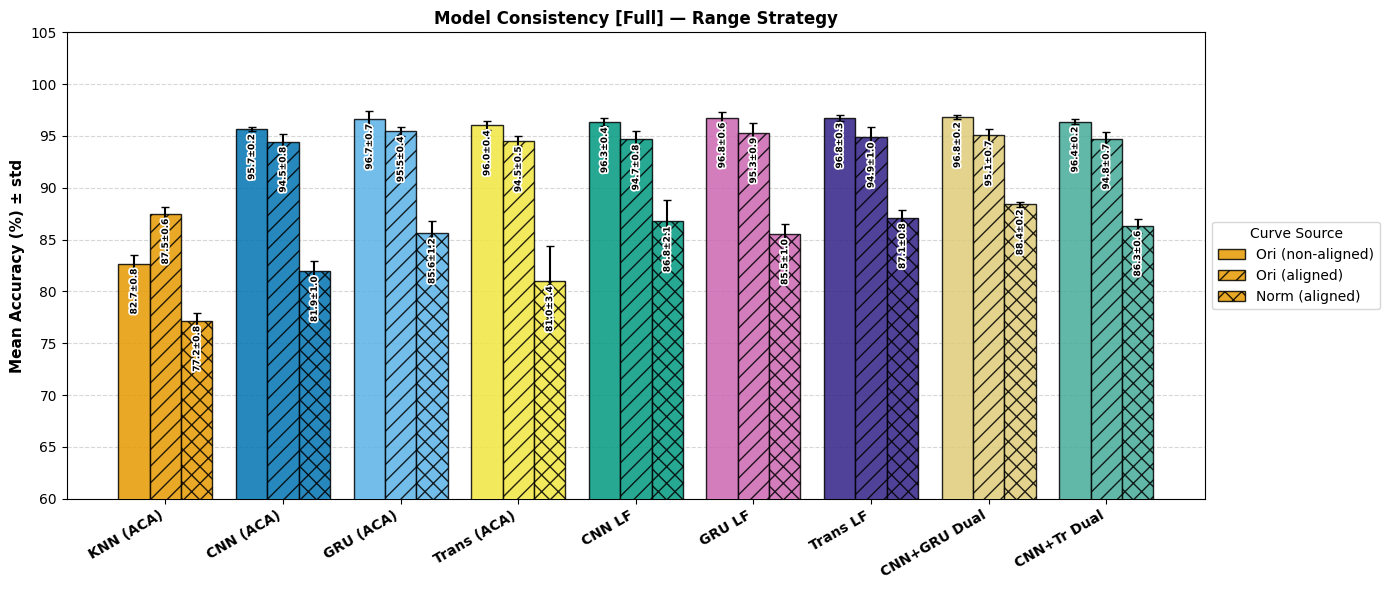

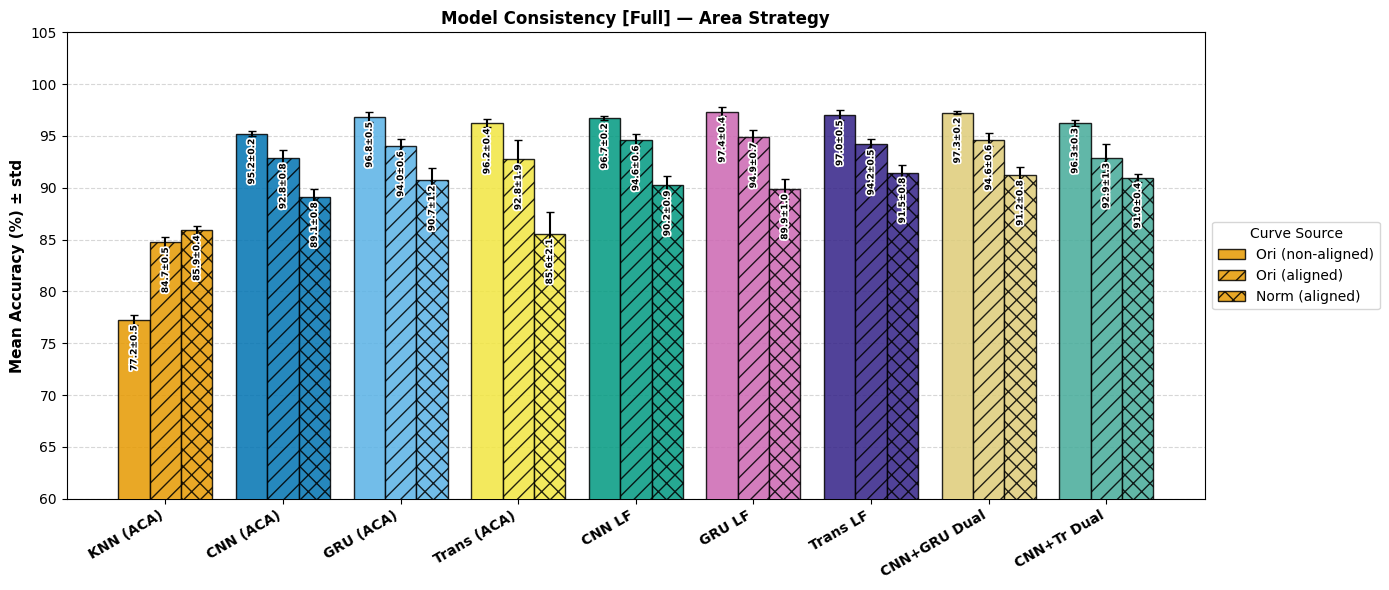

In [14]:
%matplotlib inline

ddm_df = load_lab_ddm_paper_results(training_mode="full")
plot_model_consistency_3source(ddm_df, "Z_area")            # Range Strategy
plot_model_consistency_3source(ddm_df, "Z_range_filtered")  # Area Strategy


### 2b. Confusion Matrices — Range Strategy (Z_area_aligned)

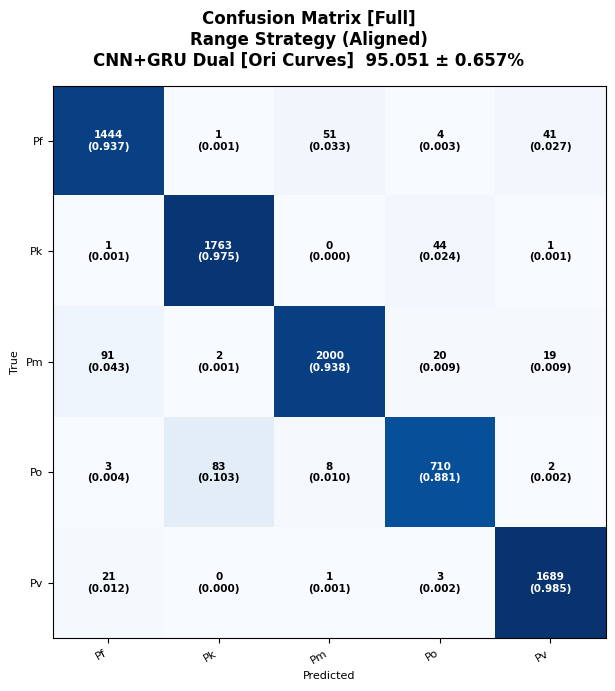

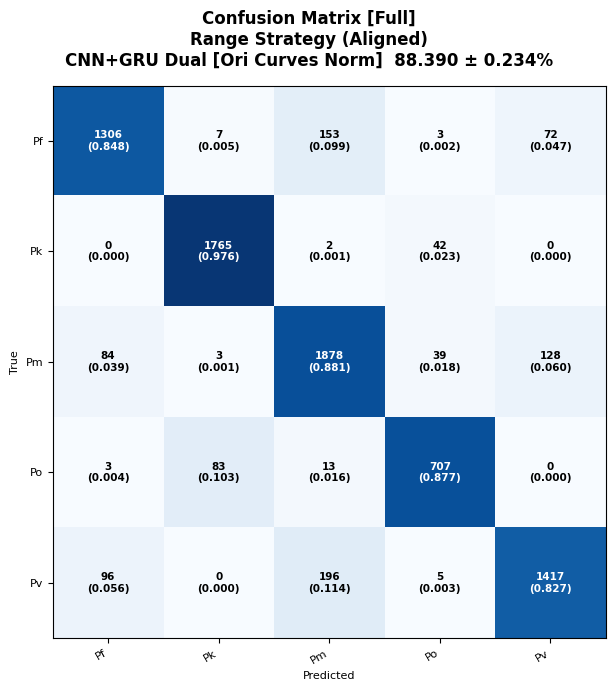

In [15]:
MODEL = "cnn_gru_dual"
plot_confusion_matrices("Z_area_aligned",           MODEL, training_mode="full", curve_type="ori_curve")
plot_confusion_matrices("Z_area_aligned",           MODEL, training_mode="full", curve_type="ori_curve_norm")


### 2c. Confusion Matrices — Area Strategy (Z_range_filtered_aligned)

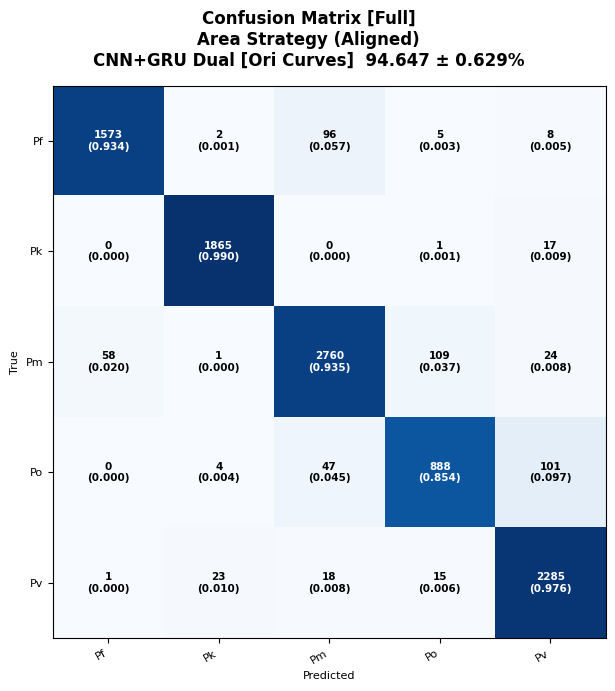

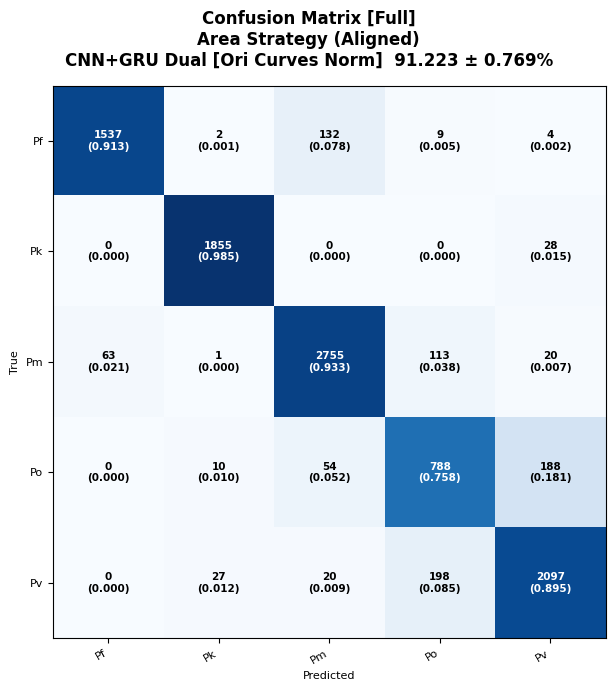

In [16]:
plot_confusion_matrices("Z_range_filtered_aligned", MODEL, training_mode="full", curve_type="ori_curve")
plot_confusion_matrices("Z_range_filtered_aligned", MODEL, training_mode="full", curve_type="ori_curve_norm")


## 3. One-to-One Classification

### 3a. Load results

In [17]:
results_ori  = load_one_to_one_results(curve_type="ori_curve")
results_norm = load_one_to_one_results(curve_type="ori_curve_norm")
results_all  = pd.concat([results_ori, results_norm], ignore_index=True)
print(f"Loaded: ori={len(results_ori)}, norm={len(results_norm)}")


Loaded: ori=179, norm=180


### 3b. Accuracy Heatmap — Range Strategy (1_area)

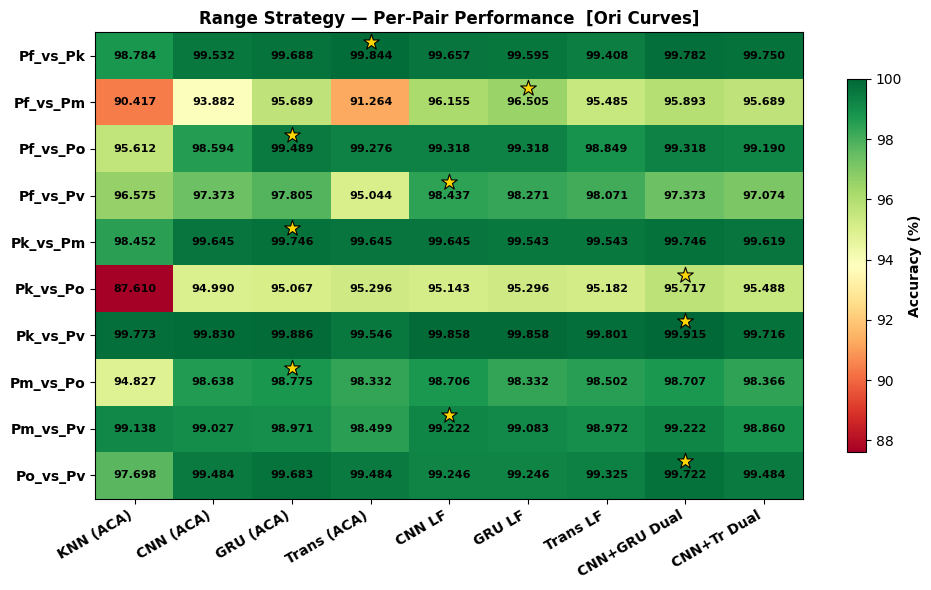

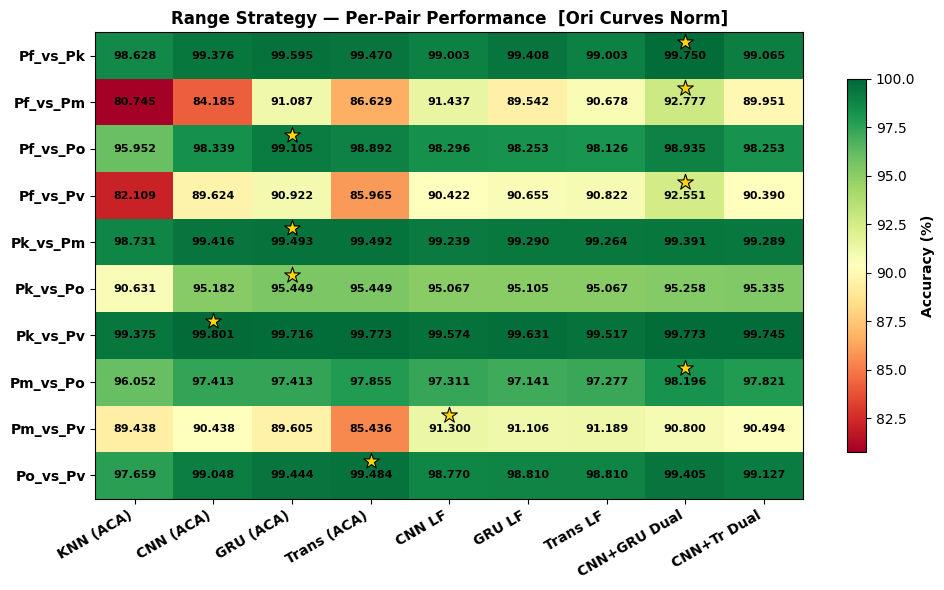

In [18]:
for ct in ["ori_curve", "ori_curve_norm"]:
    plot_accuracy_heatmap(
        results_all[results_all.strategy == "1_area"],
        "model", MODELS, "pair", PAIRS, MODEL_LABEL_MAP,
        f"{display_name('1_area')} — Per-Pair Performance",
        curve_type=ct,
    )


### 3c. Accuracy Heatmap — Area Strategy (3_range_filtered)

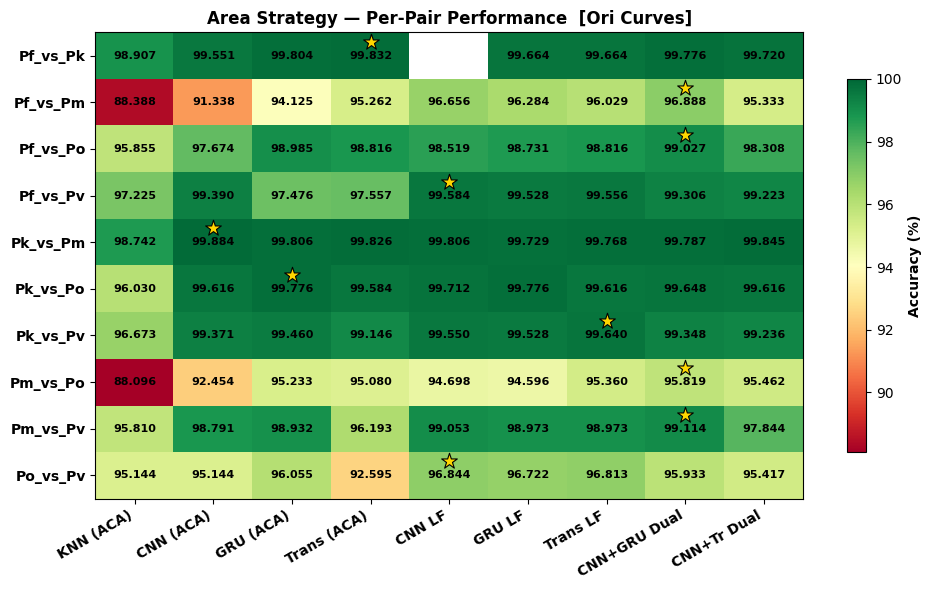

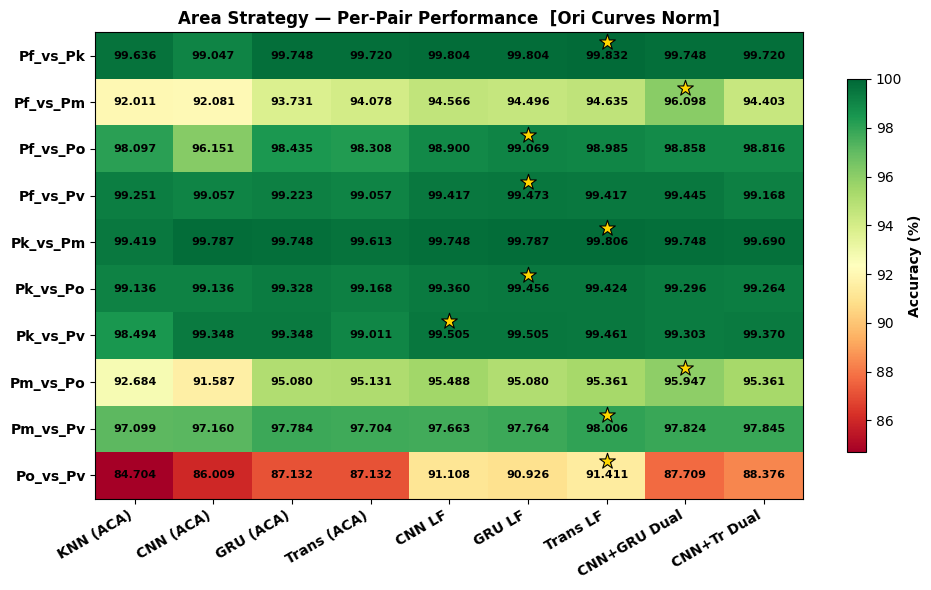

In [19]:
for ct in ["ori_curve", "ori_curve_norm"]:
    plot_accuracy_heatmap(
        results_all[results_all.strategy == "3_range_filtered"],
        "model", MODELS, "pair", PAIRS, MODEL_LABEL_MAP,
        f"{display_name('3_range_filtered')} — Per-Pair Performance",
        curve_type=ct,
    )


### 3d. Confusion Matrices — Range Strategy (1_area_aligned)

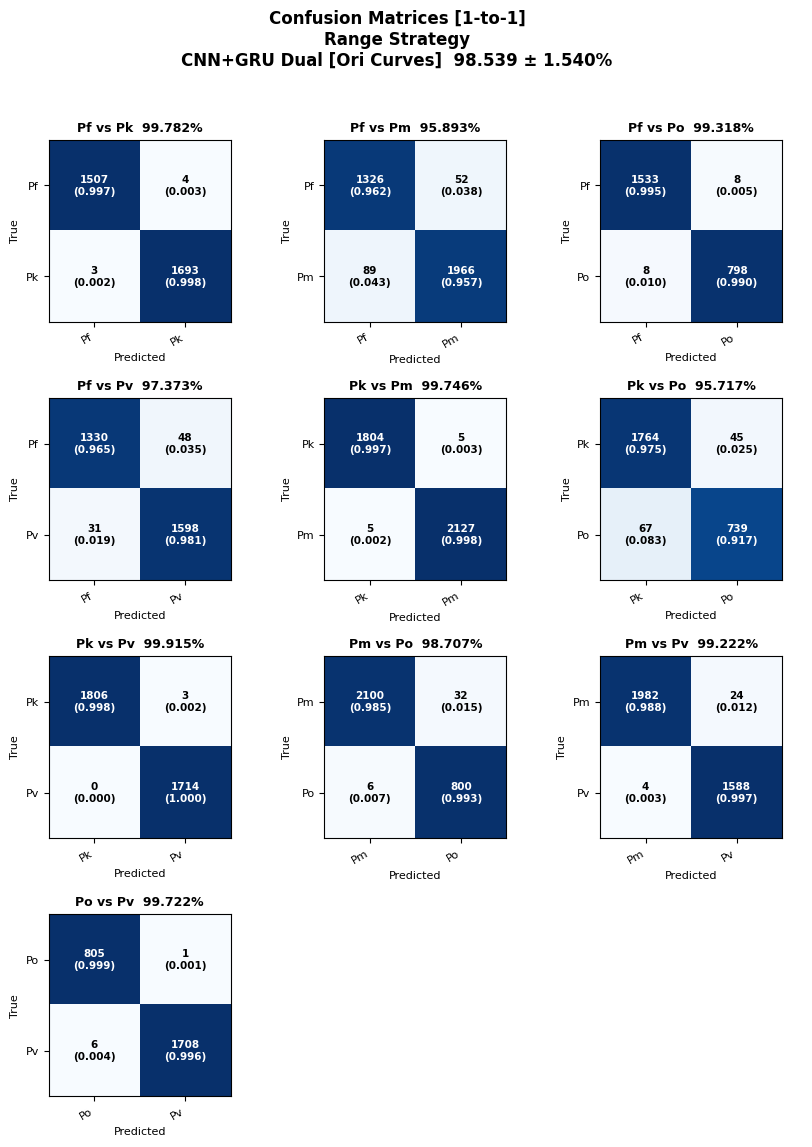

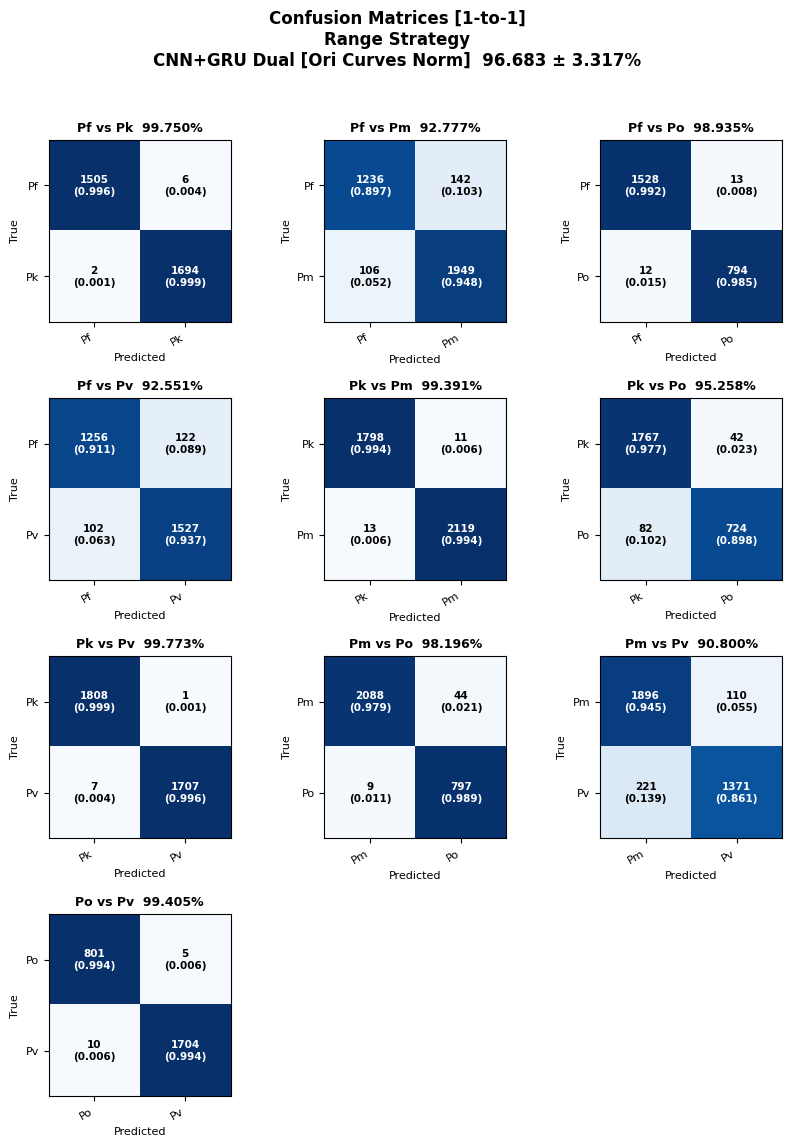

In [20]:
for ct in ["ori_curve", "ori_curve_norm"]:
    plot_confusion_matrices("1_area", MODEL, training_mode="1to1", curve_type=ct)


### 3e. Confusion Matrices — Area Strategy (3_range_filtered_aligned)

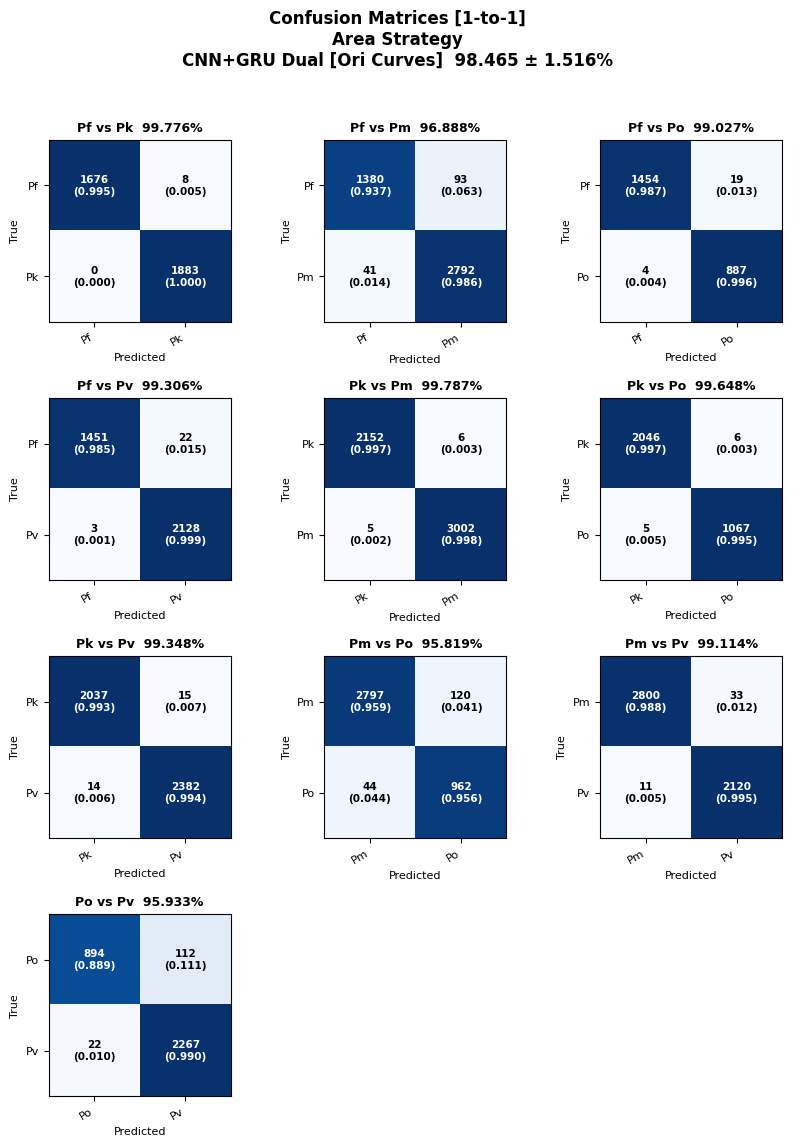

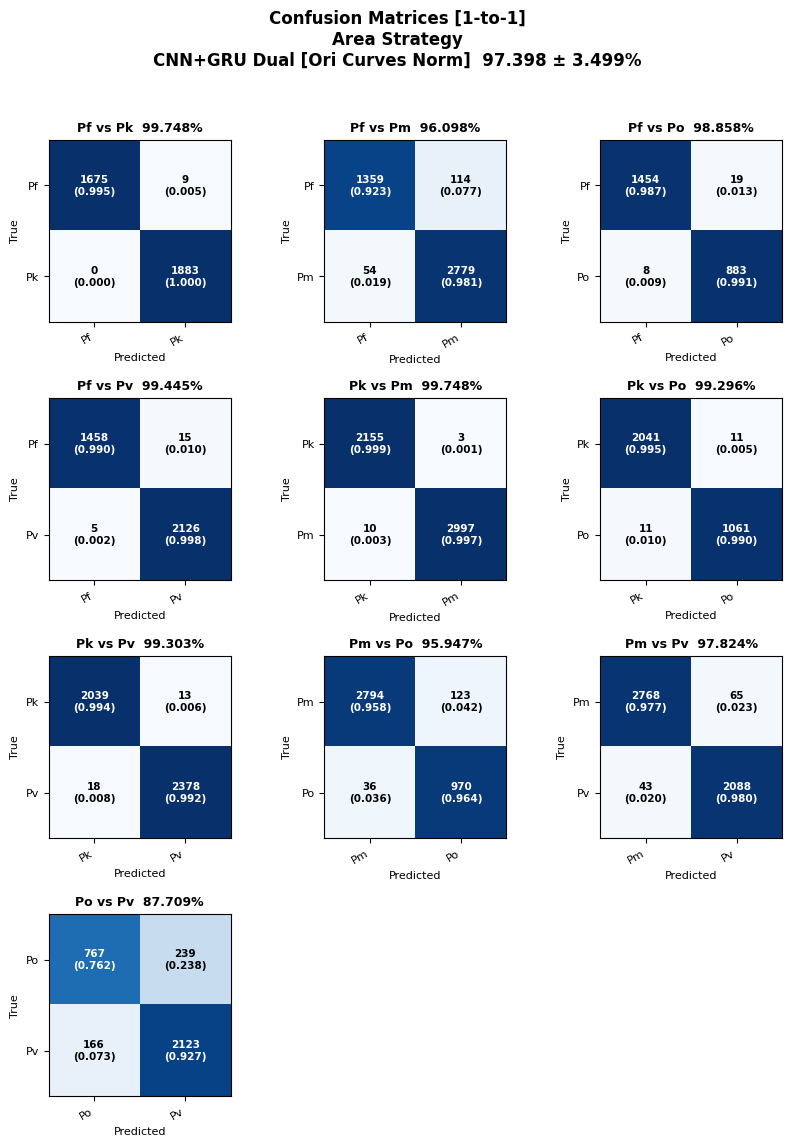

In [21]:
for ct in ["ori_curve", "ori_curve_norm"]:
    plot_confusion_matrices("3_range_filtered", MODEL, training_mode="1to1", curve_type=ct)
